In [35]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, Callback
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob

In [36]:
class DoubleConv(nn.Module):
    """Two 3x3 unpadded convolutions, each followed by ReLU [cite: 82]"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=0),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=0),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [37]:
class UNet(pl.LightningModule):
    def __init__(self, in_channels=3, out_classes=1, lr=1e-4):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr

        # Contracting Path (Encoder)
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) 

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Expanding Path (Decoder) [cite: 84]
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(1024, 512)
        
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, out_classes, kernel_size=1) 
        
        self.loss_fn = nn.BCEWithLogitsLoss()

    def forward(self, x):
        # Encoder
        s1 = self.down1(x)
        p1 = self.pool(s1)
        s2 = self.down2(p1)
        p2 = self.pool(s2)
        s3 = self.down3(p2)
        p3 = self.pool(s3)
        s4 = self.down4(p3)
        p4 = self.pool(s4)

        # Bottleneck
        bn = self.bottleneck(p4)

        # Decoder with Cropped Skip Connections [cite: 85]
        def crop_and_concat(upsampled, bypass):
            # Center crop the bypass (skip connection) to match the upsampled size
            diffY = bypass.size()[2] - upsampled.size()[2]
            diffX = bypass.size()[3] - upsampled.size()[3]
            bypass = bypass[:, :, diffY // 2 : bypass.size()[2] - diffY // 2, 
                            diffX // 2 : bypass.size()[3] - diffX // 2]
            return torch.cat((bypass, upsampled), dim=1)

        d4 = self.up4(bn)
        d4 = self.conv4(crop_and_concat(d4, s4))
        
        d3 = self.up3(d4)
        d3 = self.conv3(crop_and_concat(d3, s3))
        
        d2 = self.up2(d3)
        d2 = self.conv2(crop_and_concat(d2, s2))
        
        d1 = self.up1(d2)
        d1 = self.conv1(crop_and_concat(d1, s1))

        return self.final_conv(d1)

    # --- Metrics and Training Steps ---

    def calculate_metrics(self, pred, target):
        pred = torch.sigmoid(pred) > 0.5
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()
        dice = (2. * intersection) / (union + 1e-7)
        iou = intersection / (union - intersection + 1e-7)
        return dice, iou

    def match_target_size(self, target, output):
        # Since convolutions are unpadded, we crop the ground truth to match output size 
        diff = (target.size(2) - output.size(2)) // 2
        return target[:, :, diff:target.size(2)-diff, diff:target.size(3)-diff]

    def soft_dice_loss(self, pred_logits, target):
        """Calculates soft dice loss to prevent 0.0 metrics during early training"""
        pred = torch.sigmoid(pred_logits)
        smooth = 1.0 # Smoothing factor to avoid division by zero
        
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        
        dice_score = (2. * intersection + smooth) / (union + smooth)
        return 1 - dice_score.mean()

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        y = self.match_target_size(y, y_hat)
        
        # Hybrid Loss: BCE + Dice (Forces model to care about the small tumor)
        bce_loss = self.loss_fn(y_hat, y)
        dice_loss = self.soft_dice_loss(y_hat, y)
        loss = bce_loss + dice_loss 
        
        dice_metric, iou_metric = self.calculate_metrics(y_hat, y)
        self.log_dict({"train_loss": loss, "train_dice": dice_metric}, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        y = self.match_target_size(y, y_hat)
        
        loss = self.loss_fn(y_hat, y) + self.soft_dice_loss(y_hat, y)
        dice, iou = self.calculate_metrics(y_hat, y)
        self.log_dict({"val_loss": loss, "val_dice": dice, "val_iou": iou}, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        y = self.match_target_size(y, y_hat)
        dice, iou = self.calculate_metrics(y_hat, y)
        self.log_dict({"test_dice": dice, "test_iou": iou})

    def configure_optimizers(self):
        # Paper uses momentum 0.99 [cite: 93]
        return torch.optim.SGD(self.parameters(), lr=self.lr, momentum=0.99)

In [38]:
class BrainTumorData(Dataset):
    def __init__(self, img_paths, mask_paths):
        self.img_paths = img_paths
        self.mask_paths = mask_paths

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        
        # Resize to 572x572 as per paper input [cite: 27]
        img = cv2.resize(img, (572, 572))
        mask = cv2.resize(mask, (572, 572))

        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).unsqueeze(0).float() / 255.0
        return img, mask

In [39]:
class MetricsToTextLogger(Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        epoch = trainer.current_epoch
        with open("training_metrics_log.txt", "a") as f:
            f.write(f"Epoch: {epoch} | Val_Loss: {metrics.get('val_loss'):.4f} | "
                    f"Val_Dice: {metrics.get('val_dice'):.4f} | Val_IOU: {metrics.get('val_iou'):.4f}\n")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type              | Params | Mode  | FLOPs
------------------------------------------------------------------
0  | down1      | DoubleConv        | 38.7 K | train | 0    
1  | down2      | DoubleConv        | 221 K  | train | 0    
2  | down3      | DoubleConv        | 885 K  | train | 0    
3  | down4      | DoubleConv        | 3.5 M  | train | 0    
4  | pool       | MaxPool2d         | 0      | train | 0    
5  | bottleneck | DoubleConv        | 14.2 M | train | 0    
6  | up4        | ConvTranspose2d   | 2.1 M  | train | 0    
7  | conv4      | DoubleConv        | 7.1 M  | train | 0    
8  | up3        | ConvTranspose

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


Report image saved as brain_tumor_results.png


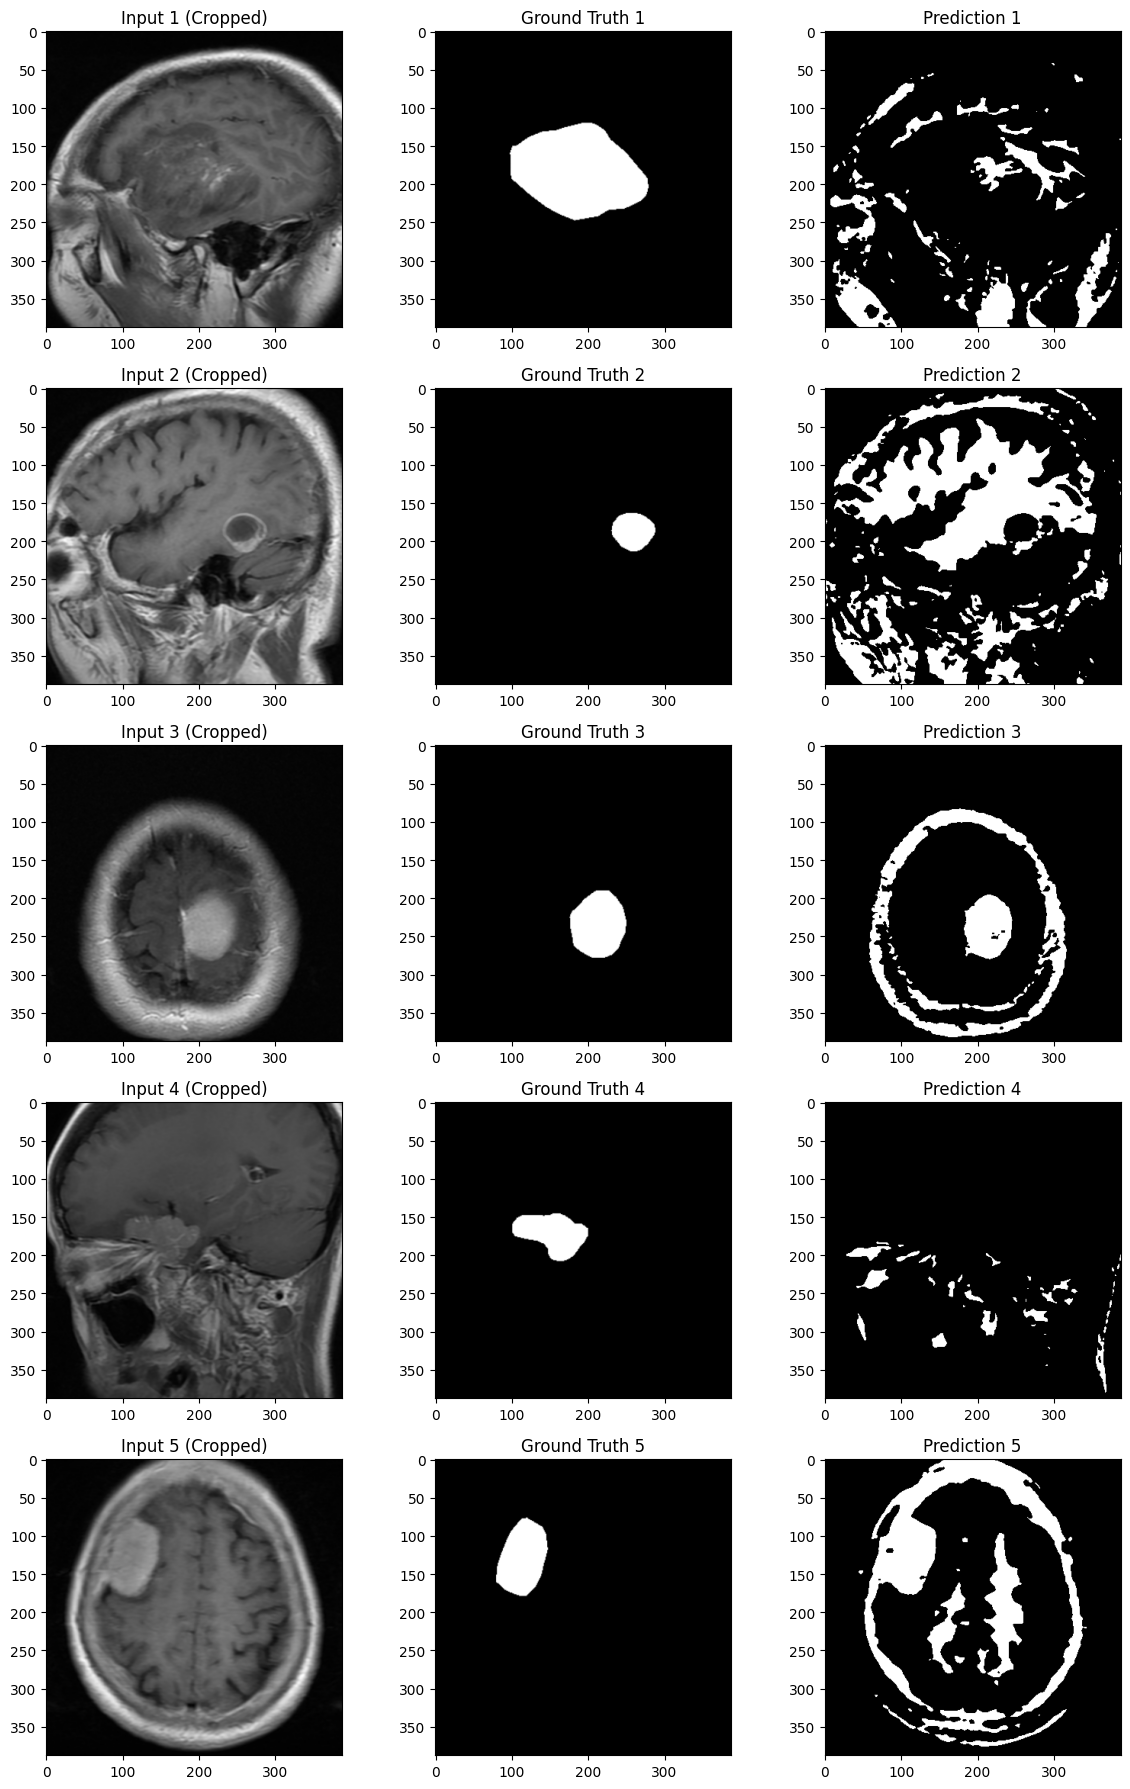

In [40]:
def main():
    image_paths = sorted(glob("dataset/images/*.png"))
    mask_paths = sorted(glob("dataset/masks/*.png"))

    dataset = BrainTumorData(image_paths, mask_paths)
    train_set, val_set, test_set = random_split(dataset, [int(len(dataset)*0.8), 
                                                           int(len(dataset)*0.1), 
                                                           len(dataset) - int(len(dataset)*0.9)])

    train_loader = DataLoader(train_set, batch_size=2, shuffle=True) # Small batch size [cite: 92]
    val_loader = DataLoader(val_set, batch_size=2)
    test_loader = DataLoader(test_set, batch_size=1)

    # 2. Training
    model = UNet()
    checkpoint_callback = ModelCheckpoint(monitor="val_dice", mode="max", save_top_k=1, filename="best-unet")
    logger_callback = MetricsToTextLogger()

    trainer = pl.Trainer(
        max_epochs=20,
        callbacks=[checkpoint_callback, logger_callback],
        accelerator="auto"
    )
    
    trainer.fit(model, train_loader, val_loader)

    # 3. Test and Visualization
    best_model = UNet.load_from_checkpoint(checkpoint_callback.best_model_path)
    best_model.eval()
    
    generate_report_image(best_model, test_loader)

def generate_report_image(model, test_loader):
    model.to("cpu")
    model.eval()
    fig, axes = plt.subplots(5, 3, figsize=(12, 18))
    
    # Iterator-ke loop-er baire niye asha hoyeche jeno reset na hoy
    test_iter = iter(test_loader)
    
    for i in range(5):
        # Protyek iteration-e unique image ashbe
        try:
            img, mask = next(test_iter)
        except StopIteration:
            break
            
        with torch.no_grad():
            pred_logits = model(img)
            pred_mask = (torch.sigmoid(pred_logits) > 0.5).float()
        
        # Paper follow kore unpadded output size (388x388) e crop kora [cite: 64, 91]
        img_crop = model.match_target_size(img, pred_mask).squeeze().permute(1, 2, 0).cpu().numpy()
        mask_crop = model.match_target_size(mask, pred_mask).squeeze().cpu().numpy()
        pred_crop = pred_mask.squeeze().cpu().numpy()

        # Display results
        axes[i, 0].imshow(img_crop)
        axes[i, 0].set_title(f"Input {i+1} (Cropped)")
        axes[i, 1].imshow(mask_crop, cmap='gray')
        axes[i, 1].set_title(f"Ground Truth {i+1}")
        axes[i, 2].imshow(pred_crop, cmap='gray')
        axes[i, 2].set_title(f"Prediction {i+1}")
        
    plt.tight_layout()
    plt.savefig("brain_tumor_results.png")
    print("Report image saved as brain_tumor_results.png")
    plt.show()

if __name__ == "__main__":
    main()